In [1]:
import pandas as pd
import os
os.getcwd()

'c:\\Users\\sagna\\OneDrive\\Desktop\\superstore dataset'

In [2]:
df = pd.read_csv(r"C:\Users\sagna\OneDrive\Desktop\Superstore_analysis\Superstore.csv", encoding="latin1")

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
print(df.dtypes)
print(df.columns)
print(df.Category)

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')
0      

In [10]:
summary = df.groupby("Category").agg(
    Total_sales=("Sales", "sum"),
    Avg_sales=("Sales", "mean"),
    Total_profit=("Profit", "sum"),
    Avg_profit=("Profit", "mean"),
    Total_quantity=("Quantity", "sum")
)
summary

,Total_sales,Avg_sales,Total_profit,Avg_profit,Total_quantity
Category,,,,,
Furniture,741999.7953,349.834887,18451.2728,8.699327,8028
Office Supplies,719047.0320,119.324101,122490.8008,20.327050,22906
Technology,836154.0330,452.709276,145454.9481,78.752002,6939


In [11]:
High_sales = df[df["Sales"] > 1000]
High_sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.184,9,0.2,85.3092
24,25,CA-2015-106320,2015-09-25,2015-09-30,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.630,3,0.0,240.2649
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430,7,0.5,-1665.0522
35,36,CA-2016-117590,2016-12-08,2016-12-10,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,TEC-PH-10004977,Technology,Phones,GE 30524EE4,1097.544,7,0.2,123.4737
54,55,CA-2016-105816,2016-12-11,2016-12-17,Standard Class,JM-15265,Janet Molinari,Corporate,United States,New York City,...,10024,East,TEC-PH-10002447,Technology,Phones,AT&T CL83451 4-Handset Telephone,1029.950,5,0.0,298.6855


In [13]:
High_sales.shape

(468, 21)

In [14]:
High_sales["Sales"].sum()

np.float64(990169.0795999999)

In [15]:
High_sales["Profit"].mean()

np.float64(314.04725918803416)

In [17]:
High_sales[High_sales["Profit"] < 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430,7,0.50,-1665.0522
165,166,CA-2014-139892,2014-09-08,2014-09-12,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,78207,Central,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,8159.952,8,0.40,-1359.9920
167,168,CA-2014-139892,2014-09-08,2014-09-12,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,78207,Central,FUR-CH-10004287,Furniture,Chairs,SAFCO Arco Folding Chair,1740.060,9,0.30,-24.8580
215,216,CA-2015-146262,2015-01-02,2015-01-09,Standard Class,VW-21775,Victoria Wilson,Corporate,United States,Medina,...,44256,East,TEC-MA-10000864,Technology,Machines,Cisco 9971 IP Video Phone Charcoal,1188.000,9,0.70,-950.4000
262,263,US-2014-106992,2014-09-19,2014-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,77036,Central,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,3059.982,3,0.40,-509.9970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9639,9640,CA-2015-116638,2015-01-28,2015-01-31,Second Class,JH-15985,Joseph Holt,Consumer,United States,Concord,...,28027,South,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.40,-1862.3124
9673,9674,CA-2016-114867,2016-12-23,2016-12-28,Standard Class,FM-14290,Frank Merwin,Home Office,United States,Philadelphia,...,19143,East,TEC-PH-10002645,Technology,Phones,LG G2,1499.970,5,0.40,-374.9925
9712,9713,CA-2014-114251,2014-11-05,2014-11-10,Standard Class,MD-17350,Maribeth Dona,Consumer,United States,Philadelphia,...,19143,East,OFF-ST-10003716,Office Supplies,Storage,Tennsco Double-Tier Lockers,1080.096,6,0.20,-94.5084
9774,9775,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,78207,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.80,-3701.8928


In [19]:
df.sort_values(by="Sales", ascending=False).head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2697,2698,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
6826,6827,CA-2016-118689,2016-10-02,2016-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,8154,CA-2017-140151,2017-03-23,2017-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2623,2624,CA-2017-127180,2017-10-22,2017-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4190,4191,CA-2017-166709,2017-11-17,2017-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,9040,CA-2016-117121,2016-12-17,2016-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,4099,CA-2014-116904,2014-09-23,2014-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
4277,4278,US-2016-107440,2016-04-16,2016-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,8701,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
8488,8489,CA-2016-158841,2016-02-02,2016-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,22204,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
6425,6426,CA-2016-143714,2016-05-23,2016-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,...,19120,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


In [23]:
df.sort_values(by="Profit", ascending=False).head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
6826,6827,CA-2016-118689,2016-10-02,2016-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,8154,CA-2017-140151,2017-03-23,2017-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
4190,4191,CA-2017-166709,2017-11-17,2017-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,9040,CA-2016-117121,2016-12-17,2016-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,4099,CA-2014-116904,2014-09-23,2014-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
2623,2624,CA-2017-127180,2017-10-22,2017-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
509,510,CA-2015-145352,2015-03-16,2015-03-22,Standard Class,CM-12385,Christopher Martinez,Consumer,United States,Atlanta,...,30318,South,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,5,0.0,3177.4750
8488,8489,CA-2016-158841,2016-02-02,2016-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,22204,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
7666,7667,US-2016-140158,2016-10-04,2016-10-08,Standard Class,DR-12940,Daniel Raglin,Home Office,United States,Providence,...,2908,East,TEC-CO-10001449,Technology,Copiers,Hewlett Packard LaserJet 3310 Copier,5399.910,9,0.0,2591.9568
6520,6521,CA-2017-138289,2017-01-16,2017-01-18,Second Class,AR-10540,Andy Reiter,Consumer,United States,Jackson,...,49201,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,5443.960,4,0.0,2504.2216


In [27]:
df.sort_values(by=["Category", "Sales"], ascending=[False, True]).head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2761,2762,CA-2017-126536,2017-10-12,2017-10-14,First Class,NK-18490,Neil Knudson,Home Office,United States,San Francisco,...,94110,West,TEC-AC-10003709,Technology,Accessories,Maxell 4.7GB DVD-R 5/Pack,0.990,1,0.0,0.4356
7900,7901,CA-2017-128363,2017-08-13,2017-08-18,Standard Class,DC-12850,Dan Campbell,Consumer,United States,Memphis,...,38109,South,TEC-AC-10003709,Technology,Accessories,Maxell 4.7GB DVD-R 5/Pack,1.584,2,0.2,0.4752
7990,7991,US-2016-117793,2016-08-23,2016-08-29,Standard Class,MA-17560,Matt Abelman,Home Office,United States,Sheboygan,...,53081,Central,TEC-AC-10003433,Technology,Accessories,Maxell 4.7GB DVD+R 5/Pack,1.980,2,0.0,0.8910
9545,9546,CA-2014-166590,2014-10-29,2014-11-02,Standard Class,NC-18625,Noah Childs,Corporate,United States,Columbus,...,47201,Central,TEC-AC-10003433,Technology,Accessories,Maxell 4.7GB DVD+R 5/Pack,1.980,2,0.0,0.8910
2779,2780,CA-2017-108322,2017-04-30,2017-05-05,Standard Class,SS-20140,Saphhira Shifley,Corporate,United States,Pompano Beach,...,33068,South,TEC-AC-10003433,Technology,Accessories,Maxell 4.7GB DVD+R 5/Pack,2.376,3,0.2,0.7425
9163,9164,CA-2015-164007,2015-06-08,2015-06-12,Standard Class,MG-17695,Maureen Gnade,Consumer,United States,Chicago,...,60610,Central,TEC-AC-10003433,Technology,Accessories,Maxell 4.7GB DVD+R 5/Pack,2.376,3,0.2,0.7425
1330,1331,CA-2017-127705,2017-06-02,2017-06-06,Standard Class,AB-10255,Alejandro Ballentine,Home Office,United States,Lorain,...,44052,East,TEC-PH-10000347,Technology,Phones,Cush Cases Heavy Duty Rugged Cover Case for Sa...,2.970,1,0.4,-0.6435
3269,3270,CA-2014-115980,2014-07-15,2014-07-19,Standard Class,VW-21775,Victoria Wilson,Corporate,United States,Sioux Falls,...,57103,Central,TEC-AC-10003709,Technology,Accessories,Maxell 4.7GB DVD-R 5/Pack,2.970,3,0.0,1.3068
7926,7927,CA-2017-120404,2017-11-20,2017-11-24,Second Class,KH-16330,Katharine Harms,Corporate,United States,New York City,...,10035,East,TEC-AC-10003433,Technology,Accessories,Maxell 4.7GB DVD+R 5/Pack,2.970,3,0.0,1.3365
9621,9622,CA-2014-115133,2014-09-26,2014-09-30,Standard Class,DA-13450,Dianna Arnett,Home Office,United States,Lancaster,...,43130,East,TEC-AC-10002370,Technology,Accessories,Maxell CD-R Discs,3.152,2,0.2,0.4728


In [28]:
df.nlargest(10, "Sales")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2697,2698,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
6826,6827,CA-2016-118689,2016-10-02,2016-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,8154,CA-2017-140151,2017-03-23,2017-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2623,2624,CA-2017-127180,2017-10-22,2017-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4190,4191,CA-2017-166709,2017-11-17,2017-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,9040,CA-2016-117121,2016-12-17,2016-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,4099,CA-2014-116904,2014-09-23,2014-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
4277,4278,US-2016-107440,2016-04-16,2016-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,8701,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
8488,8489,CA-2016-158841,2016-02-02,2016-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,22204,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
6425,6426,CA-2016-143714,2016-05-23,2016-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,...,19120,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


In [32]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [5]:
df.groupby("Category")["Profit"].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [7]:
df.groupby("Region")["Sales"].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

In [12]:
df.groupby("Region")["Profit"].sum()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

In [9]:
df.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
})

,Sales,Profit,Quantity
Category,,,
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906
Technology,836154.0330,145454.9481,6939


In [13]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [16]:
df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [17]:
df.groupby("Segment")["Profit"].sum()

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

In [20]:
df.groupby(["Region", "Category"])["Sales"].sum().sort_values(ascending=False)

Region   Category       
East     Technology         264973.9810
West     Furniture          252612.7435
         Technology         251991.8320
         Office Supplies    220853.2490
East     Furniture          208291.2040
         Office Supplies    205516.0550
Central  Technology         170416.3120
         Office Supplies    167026.4150
         Furniture          163797.1638
South    Technology         148771.9080
         Office Supplies    125651.3130
         Furniture          117298.6840
Name: Sales, dtype: float64

In [21]:
df.groupby(["Region", "Category"]).agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
})

Sales      Profit  Quantity
Region  Category                                          
Central Furniture        163797.1638  -2871.0494      1827
        Office Supplies  167026.4150   8879.9799      5409
        Technology       170416.3120  33697.4320      1544
East    Furniture        208291.2040   3046.1658      2214
        Office Supplies  205516.0550  41014.5791      6462
        Technology       264973.9810  47462.0351      1942
South   Furniture        117298.6840   6771.2061      1291
        Office Supplies  125651.3130  19986.3928      3800
        Technology       148771.9080  19991.8314      1118
West    Furniture        252612.7435  11504.9503      2696
        Office Supplies  220853.2490  52609.8490      7235
        Technology       251991.8320  44303.6496      2335

In [22]:
df.groupby(["Region", "Category"])["Sales"].sum().reset_index()

,Region,Category,Sales
0,Central,Furniture,163797.1638
1,Central,Office Supplies,167026.4150
2,Central,Technology,170416.3120
3,East,Furniture,208291.2040
4,East,Office Supplies,205516.0550
5,East,Technology,264973.9810
6,South,Furniture,117298.6840
7,South,Office Supplies,125651.3130
8,South,Technology,148771.9080
9,West,Furniture,252612.7435


In [26]:
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(20)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64

In [28]:
df.groupby(["Region", "Segment"])["Sales"].sum().sort_values(ascending=False)

Region   Segment    
West     Consumer       362880.7730
East     Consumer       350908.1670
Central  Consumer       252031.4340
West     Corporate      225855.2745
East     Corporate      200409.3470
South    Consumer       195580.9710
Central  Corporate      157995.8128
West     Home Office    136721.7770
East     Home Office    127463.7260
South    Corporate      121885.9325
Central  Home Office     91212.6440
South    Home Office     74255.0015
Name: Sales, dtype: float64

In [29]:
df.groupby(["Category", "Sub-Category"])["Profit"].sum().sort_values(ascending=False)

Category         Sub-Category
Technology       Copiers         55617.8249
                 Phones          44515.7306
                 Accessories     41936.6357
Office Supplies  Paper           34053.5693
                 Binders         30221.7633
Furniture        Chairs          26590.1663
Office Supplies  Storage         21278.8264
                 Appliances      18138.0054
Furniture        Furnishings     13059.1436
Office Supplies  Envelopes        6964.1767
                 Art              6527.7870
                 Labels           5546.2540
Technology       Machines         3384.7569
Office Supplies  Fasteners         949.5182
                 Supplies        -1189.0995
Furniture        Bookcases       -3472.5560
                 Tables         -17725.4811
Name: Profit, dtype: float64

In [32]:
df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(5)

City
New York City    256368.161
Los Angeles      175851.341
Seattle          119540.742
San Francisco    112669.092
Philadelphia     109077.013
Name: Sales, dtype: float64

In [34]:
pd.pivot_table(df, values="Sales", index="Region", aggfunc="sum")

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


In [39]:
pd.pivot_table(df, values="Sales", index="Region", columns="Category", aggfunc="sum")

Category,Furniture,Office Supplies,Technology
Region,,,
Central,163797.1638,167026.415,170416.312
East,208291.2040,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


In [40]:
pd.pivot_table(
    df,
    values=["Sales", "Profit"],
    index="Region",
    columns="Category",
    aggfunc="sum"
    
)

Profit                                    Sales                  \
Category   Furniture Office Supplies  Technology    Furniture Office Supplies   
Region                                                                          
Central   -2871.0494       8879.9799  33697.4320  163797.1638      167026.415   
East       3046.1658      41014.5791  47462.0351  208291.2040      205516.055   
South      6771.2061      19986.3928  19991.8314  117298.6840      125651.313   
West      11504.9503      52609.8490  44303.6496  252612.7435      220853.249   

                      
Category  Technology  
Region                
Central   170416.312  
East      264973.981  
South     148771.908  
West      251991.832

In [42]:
pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum",
    margins=True
)

Category,Furniture,Office Supplies,Technology,All
Region,,,,
Central,163797.1638,167026.415,170416.312,5.012399e+05
East,208291.2040,205516.055,264973.981,6.787812e+05
South,117298.6840,125651.313,148771.908,3.917219e+05
West,252612.7435,220853.249,251991.832,7.254578e+05
All,741999.7953,719047.032,836154.033,2.297201e+06


In [43]:
pd.pivot_table(
    df,
    values="Sales",
    index="Category",
    aggfunc="mean"
)

,Sales
Category,
Furniture,349.834887
Office Supplies,119.324101
Technology,452.709276


In [44]:
pd.pivot_table(
    df,
    values="Profit",
    index="Sub-Category",
    aggfunc="sum"
).sort_values("Profit", ascending=False)

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


In [45]:
pd.pivot_table(df, index="Region", columns="Segment", values="Sales", aggfunc="sum")

Segment,Consumer,Corporate,Home Office
Region,,,
Central,252031.434,157995.8128,91212.6440
East,350908.167,200409.3470,127463.7260
South,195580.971,121885.9325,74255.0015
West,362880.773,225855.2745,136721.7770


In [46]:
pd.pivot_table(df, index="Region", columns="Category", values="Profit", aggfunc="sum")

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2871.0494,8879.9799,33697.4320
East,3046.1658,41014.5791,47462.0351
South,6771.2061,19986.3928,19991.8314
West,11504.9503,52609.8490,44303.6496


In [47]:
pd.pivot_table(df, values="Quantity", index="Category", aggfunc="sum")

,Quantity
Category,
Furniture,8028
Office Supplies,22906
Technology,6939


In [6]:
df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [7]:
df.groupby("Product Name")["Profit"].sum().sort_values().head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [14]:
def top_profitable_products(df, n=10):
    return df.groupby("Product Name")["Profit"]\
             .sum()\
             .sort_values(ascending=False)\
             .head(n)

In [16]:
top_profitable_products(df)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [17]:
def worst_profitable_products(df, n=10):
    return df.groupby("Product Name")["Profit"]\
             .sum()\
             .sort_values()\
             .head(10)

In [18]:
worst_profitable_products(df)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [20]:
def profit_by_subcategory(df):
    return df.groupby("Sub-Category")["Profit"]\
             .sum()\
             .sort_values()

In [21]:
profit_by_subcategory(df)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

In [9]:
df.groupby("Customer Name")["Sales"].sum()

Customer Name
Aaron Bergman          886.156
Aaron Hawkins         1744.700
Aaron Smayling        3050.692
Adam Bellavance       7755.620
Adam Hart             3250.337
                        ...   
Xylona Preis          2374.658
Yana Sorensen         6720.444
Yoseph Carroll        5454.350
Zuschuss Carroll      8025.707
Zuschuss Donatelli    1493.944
Name: Sales, Length: 793, dtype: float64

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

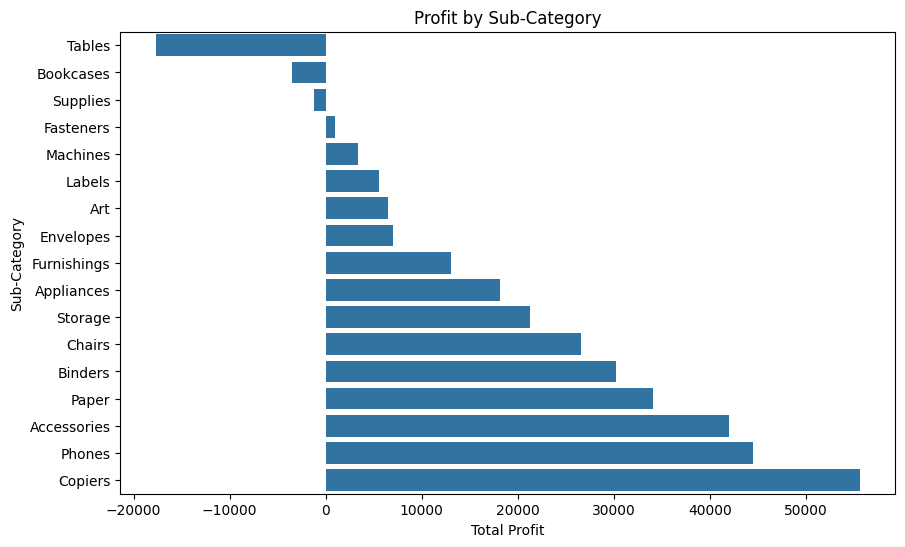

In [5]:
profit_subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values()

plt.figure(figsize=(10,6))
sns.barplot(
    x=profit_subcat.values,
    y=profit_subcat.index
)

plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.show()

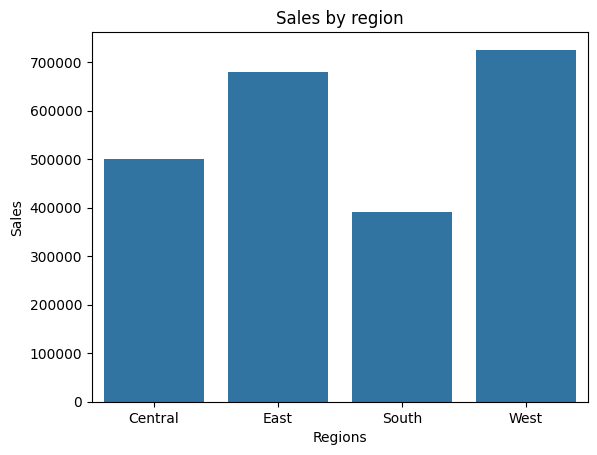

In [29]:
sales_region = df.groupby("Region")["Sales"].sum()

sns.barplot(
    x=sales_region.index,
    y=sales_region.values
)

plt.title("Sales by region")
plt.xlabel("Regions")
plt.ylabel("Sales")
plt.show()

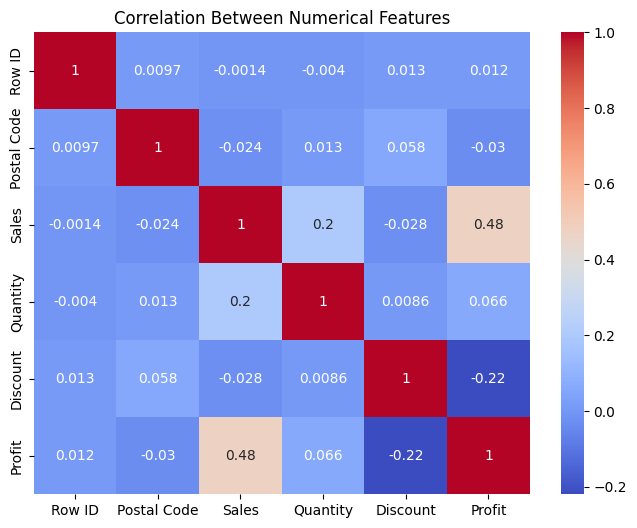

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features")
plt.show()

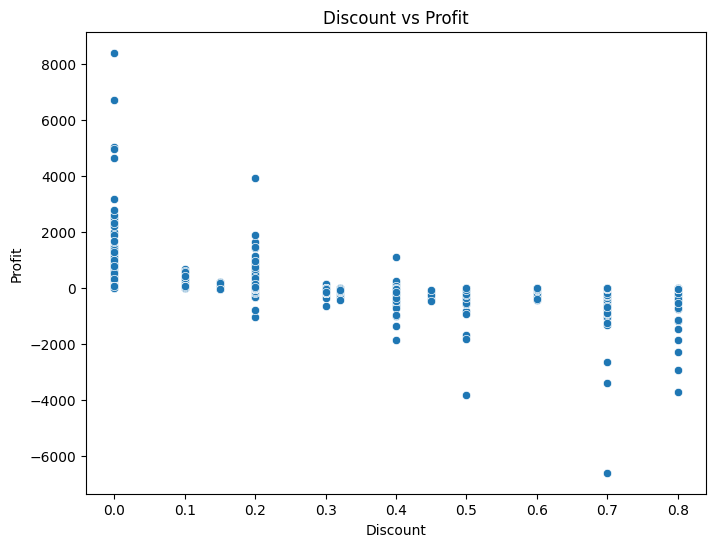

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.show()

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
Sales_by_year = df.groupby(df["Order Date"].dt.year)["Sales"].sum()
Sales_by_year

Order Date
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

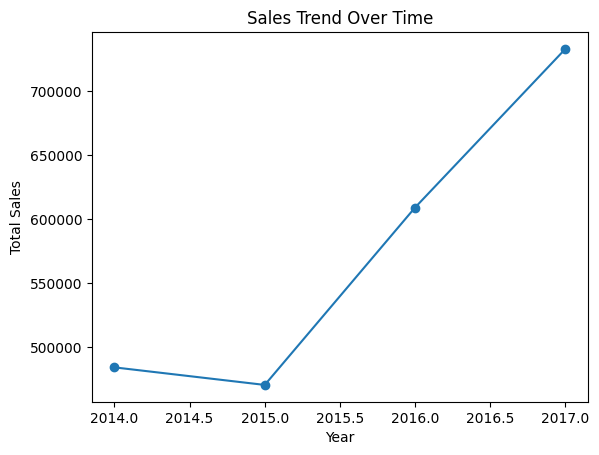

In [13]:
Sales_by_year.plot(kind="line", marker="o")

plt.title("Sales Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

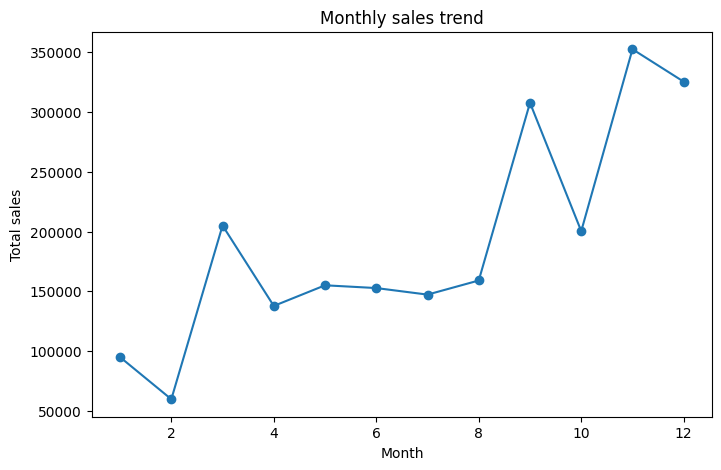

In [8]:
sales_by_month = df.groupby(df["Order Date"].dt.month)["Sales"].sum()
sales_by_month.plot(kind="line", marker="o", figsize=(8,5))

plt.title("Monthly sales trend")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.show()

In [11]:
df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

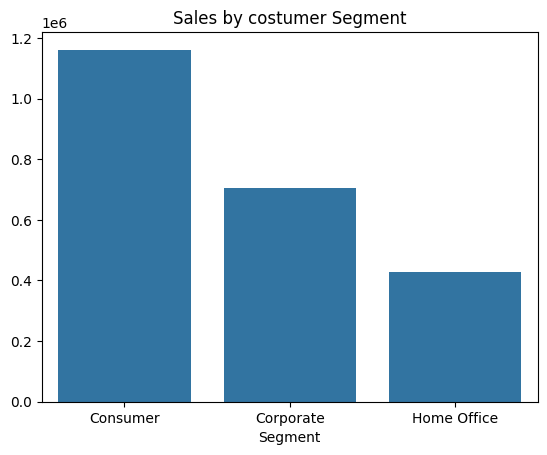

In [13]:
Segment_sales = df.groupby("Segment")["Sales"].sum()

sns.barplot(
    x=Segment_sales.index,
    y=Segment_sales.values
)

plt.title("Sales by costumer Segment")
plt.show()

In [ ]:
#The Consumer segment spent the most with almost 1.2 followed by the corporate segment with around 0.7 and the home office spent the least with 0.4.
#The Consumer segment generates the majority of revenue, accounting for more than half of total sales. This means the business is primarily B2C (Business-to-Consumer).

In [14]:
df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

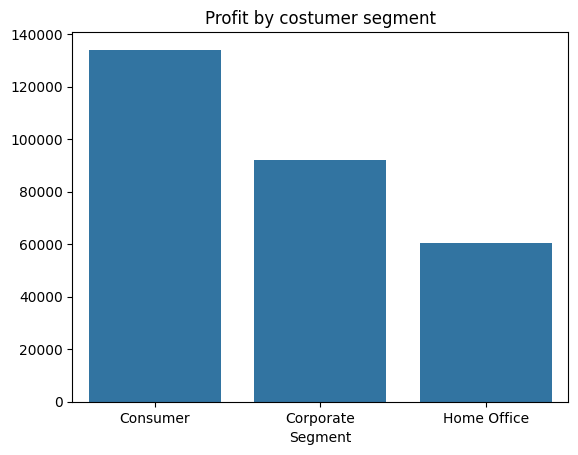

In [18]:
Segment_profit = df.groupby("Segment")["Profit"].sum()

sns.barplot(
    x = Segment_profit.index,
    y = Segment_profit.values
)

plt.title("Profit by costumer segment")
plt.show()

In [ ]:
#Consumer generates the most profit with over 120000 and the corporate segment generates only around 90000 and the home office with the least significant profit with 60000

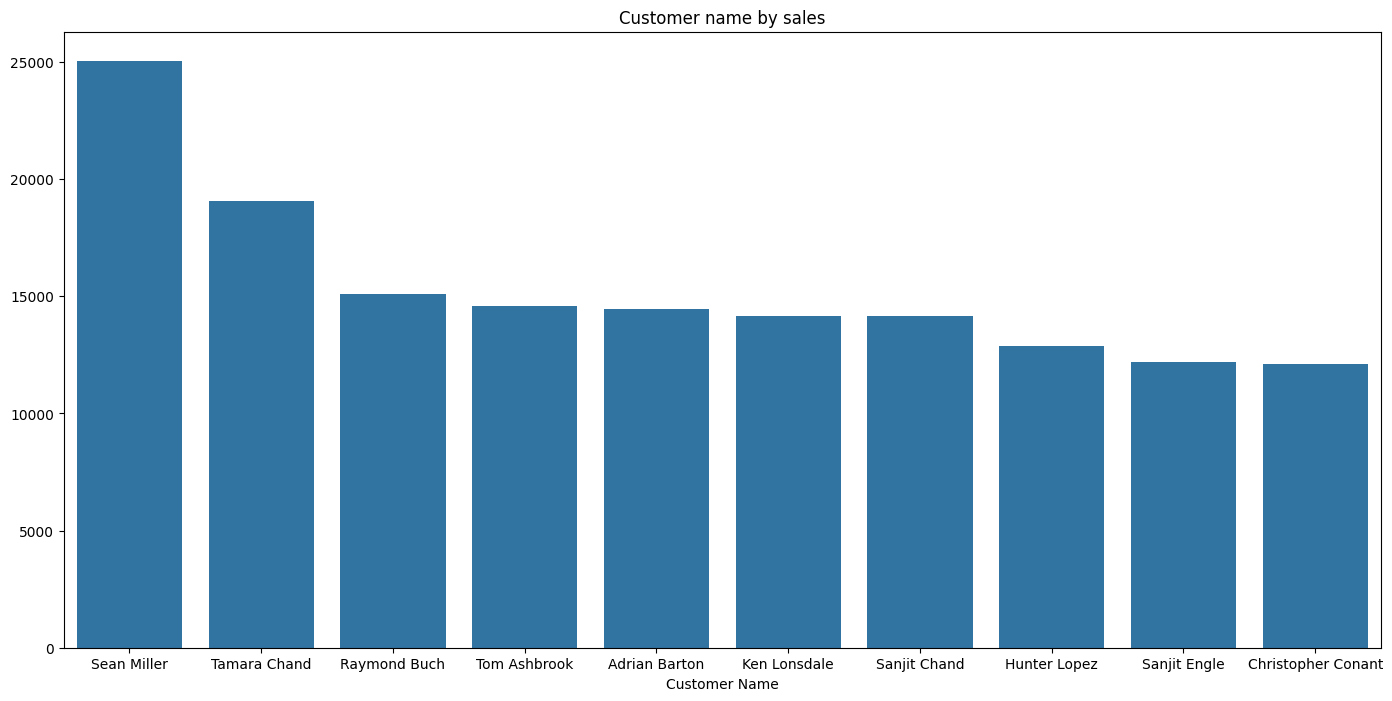

In [54]:
customerNames_sales = df.groupby("Customer Name")["Sales"]\
                        .sum()\
                        .sort_values(ascending=False)\
                        .head(10)

plt.figure(figsize=(17,8))
sns.barplot(
    x=customerNames_sales.index,
    y=customerNames_sales.values
)

plt.title("Customer name by sales")
plt.show()

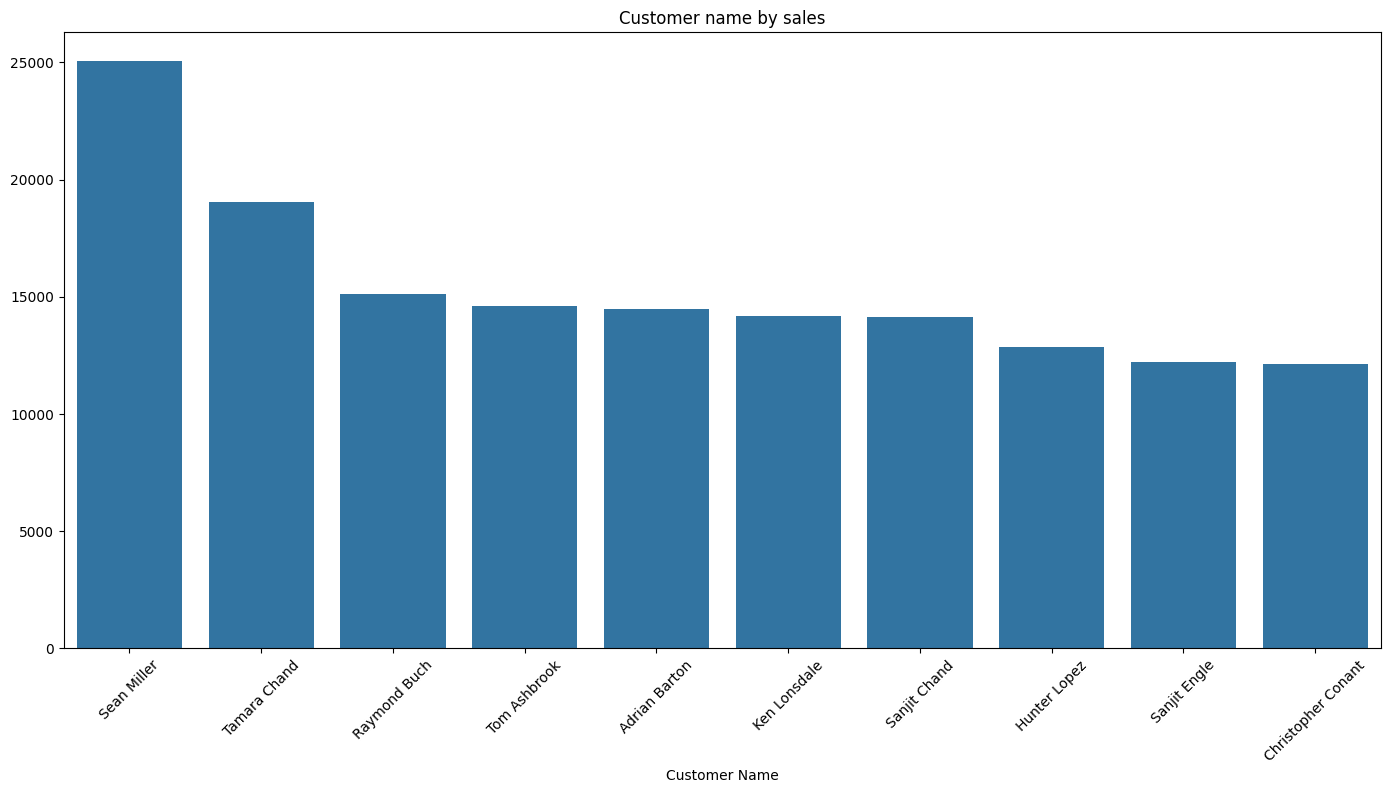

In [55]:
customerNames_sales = df.groupby("Customer Name")["Sales"]\
                        .sum()\
                        .sort_values(ascending=False)\
                        .head(10)

plt.figure(figsize=(17,8))
sns.barplot(
    x=customerNames_sales.index,
    y=customerNames_sales.values
)

plt.title("Customer name by sales")
plt.xticks(rotation=45)
plt.show()

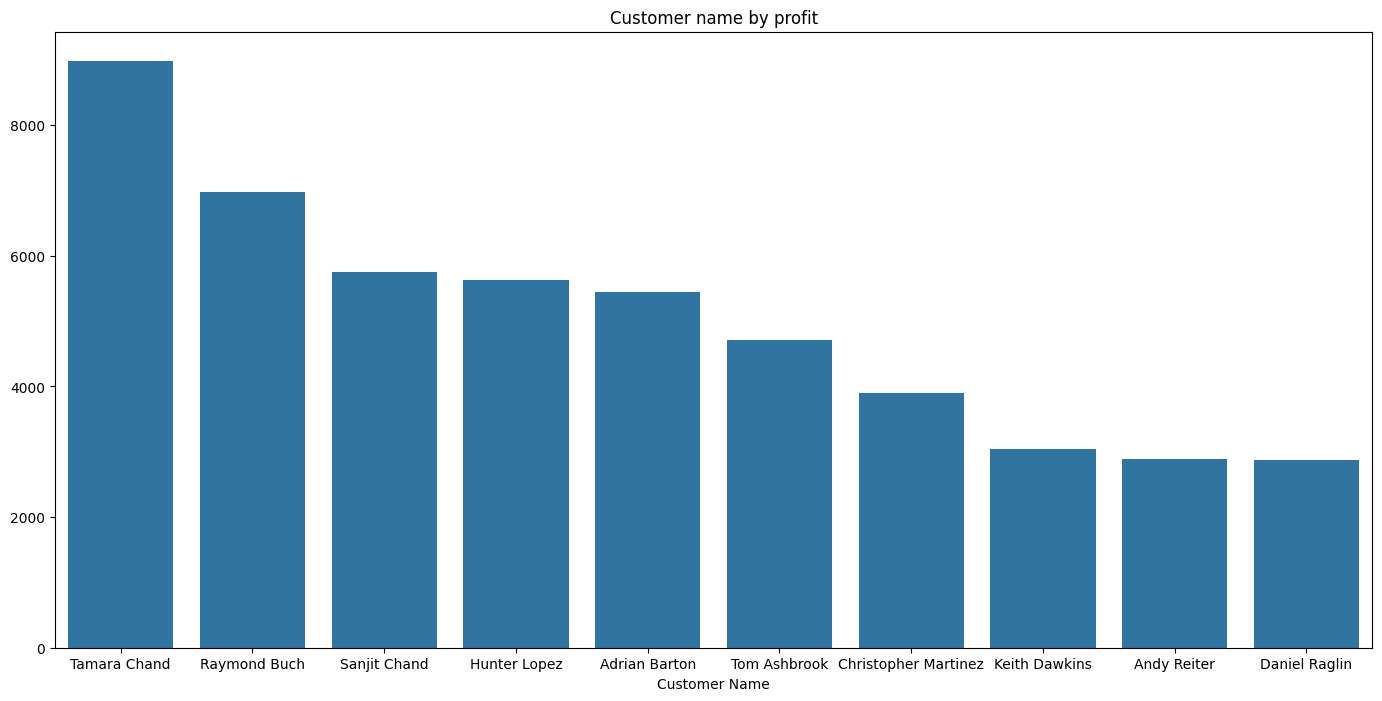

In [57]:
customerNames_by_profit = df.groupby("Customer Name")["Profit"]\
                            .sum()\
                            .sort_values(ascending=False)\
                            .head(10)

plt.figure(figsize=(17,8))
sns.barplot(
    x = customerNames_by_profit.index,
    y = customerNames_by_profit.values
)

plt.title("Customer name by profit")
plt.show()

In [ ]:
#While Sean Miller generated the highest sales revenue, Tamara Chand and Raymond Buch generated the highest profits. This indicates that high sales volume does not always translate into the highest profitability.

In [6]:
plt.savefig("sales_by_region.png")

<Figure size 640x480 with 0 Axes>

<Axes: xlabel='Sales'>

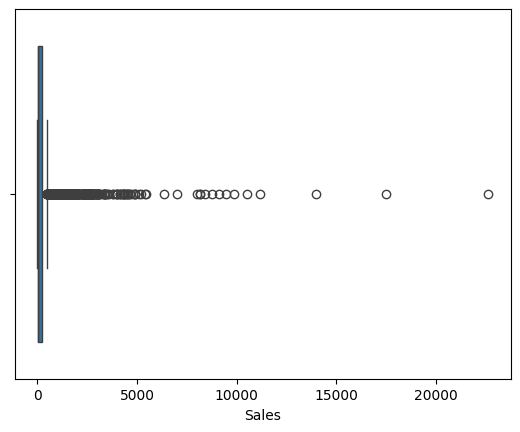

In [7]:
sns.boxplot(x=df["Sales"])